<a href="https://colab.research.google.com/github/ofAiden/Duplicate-Charged-Particle-Tracks-with-ML-professor-Tuna/blob/main/embed_train_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import uproot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import awkward as ak # Using awkward array for easier handling of jagged data
import time # For timing steps

# Set seeds for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

def load_root_file(file_path, branches=None, print_branches=False):
    all_branches = {}
    with uproot.open(file_path) as file:
        tree = file["tree"]
        # Load all ROOT branches into array if not specified
        if branches is None:
            branches = tree.keys()
        # Option to print the branch names
        if print_branches:
            print("Branches:", tree.keys())
        # Each branch is added to the dictionary
        for branch in branches:
            try:
                all_branches[branch] = (tree[branch].array(library="np"))
            except uproot.KeyInFileError as e:
                print(f"KeyInFileError: {e}")
        # Number of events in file
        all_branches['event'] = tree.num_entries
    return all_branches

branches_list = [
    't5_innerRadius',
    't5_bridgeRadius',
    't5_outerRadius',
    't5_pt',
    't5_eta',
    't5_phi',
    't5_isFake',
    't5_t3_idx0',
    't5_t3_idx1',

    't5_t3_fakeScore1',
    't5_t3_promptScore1',
    't5_t3_displacedScore1',
    't5_t3_fakeScore2',
    't5_t3_promptScore2',
    't5_t3_displacedScore2',

    't5_pMatched',
    't5_sim_vxy',
    't5_sim_vz',
    't5_matched_simIdx'
]

branches_list += [
    'pLS_eta',
    'pLS_etaErr',
    'pLS_phi',
    'pLS_matched_simIdx',
    'pLS_circleCenterX',
    'pLS_circleCenterY',
    'pLS_circleRadius',
    'pLS_ptIn',
    'pLS_ptErr',
    'pLS_px',
    'pLS_py',
    'pLS_pz',
    'pLS_isQuad',
    'pLS_isFake'
]

# Hit-dependent branches
suffixes = ['r', 'z', 'eta', 'phi', 'layer']
branches_list += [f't5_t3_{i}_{suffix}' for i in [0, 2, 4] for suffix in suffixes]

!pip install gdown

import gdown

# 1. The Google Drive File ID (found in the shareable link)
# Example: if link is https://drive.google.com/file/d/1ABC123.../view, ID is '1ABC123...'
file_id = '1l0NvKngLrY7HZxx69ZrnLYEWWvTwmM5f'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Where you want to save the file locally
file_path = 'data_file.root'

# 3. Download logic
if not os.path.exists(file_path):
    print(f"Downloading {file_path} from Google Drive...")
    gdown.download(url, file_path, quiet=False)
else:
    print(f"File '{file_path}' already exists locally. Skipping download.")

branches = load_root_file(file_path, branches_list, print_branches=True)

File 'data_file.root' already exists locally. Skipping download.
Branches: ['sim_pt', 'sim_eta', 'sim_phi', 'sim_pca_dxy', 'sim_pca_dz', 'sim_q', 'sim_event', 'sim_pdgId', 'sim_vx', 'sim_vy', 'sim_vz', 'sim_trkNtupIdx', 'sim_TC_matched', 'sim_TC_matched_mask', 'tc_pt', 'tc_eta', 'tc_phi', 'tc_type', 'tc_isFake', 'tc_isDuplicate', 'tc_matched_simIdx', 'sim_dummy', 'tc_dummy', 'pT5_matched_simIdx', 'pT5_hitIdxs', 'sim_pT5_matched', 'pT5_pt', 'pT5_eta', 'pT5_phi', 'pT5_isFake', 't5_sim_vxy', 't5_sim_vz', 'pT5_isDuplicate', 'pT5_score', 'pT5_layer_binary', 'pT5_moduleType_binary', 'pT5_matched_pt', 'pT5_rzChiSquared', 'pT5_rPhiChiSquared', 'pT5_rPhiChiSquaredInwards', 'sim_pT3_matched', 'pT3_pt', 'pT3_isFake', 'pT3_isDuplicate', 'pT3_eta', 'pT3_phi', 'pT3_score', 'pT3_foundDuplicate', 'pT3_matched_simIdx', 'pT3_hitIdxs', 'pT3_pixelRadius', 'pT3_pixelRadiusError', 'pT3_matched_pt', 'pT3_tripletRadius', 'pT3_rPhiChiSquared', 'pT3_rPhiChiSquaredInwards', 'pT3_rzChiSquared', 'pT3_layer_binary'

In [2]:
z_max = np.max([np.max(event) for event in branches[f't5_t3_4_z']])
r_max = np.max([np.max(event) for event in branches[f't5_t3_4_r']])
eta_max = 2.5
phi_max = np.pi
n_events = np.shape(branches['t5_pt'])[0]

print(f'Z max: {z_max}, R max: {r_max}, Eta max: {eta_max}')

def delta_phi(phi1, phi2):
    delta = phi1 - phi2
    # Adjust delta to be within the range [-pi, pi]
    if delta > np.pi:
        delta -= 2 * np.pi
    elif delta < -np.pi:
        delta += 2 * np.pi
    return delta


Z max: 267.2349853515625, R max: 110.10993957519531, Eta max: 2.5


In [3]:
pMATCHED_THRESHOLD = 0.        # keep if t5_pMatched >= this
print(f"\nBuilding T5 features  (pMatched >= {pMATCHED_THRESHOLD}) ...")

features_per_event    = []
eta_per_event         = []
displaced_per_event = []
sim_indices_per_event = []

kept_tot, init_tot = 0, 0
for ev in range(n_events):

    n_t5 = len(branches['t5_t3_idx0'][ev])
    init_tot += n_t5
    if n_t5 == 0:
        continue

    feat_evt = []
    eta_evt  = []
    sim_evt  = []
    disp_evt = []

    for i in range(n_t5):
        if branches['t5_pMatched'][ev][i] < pMATCHED_THRESHOLD:
            continue

        idx0 = branches['t5_t3_idx0'][ev][i]
        idx1 = branches['t5_t3_idx1'][ev][i]

        # hit-level quantities
        eta1 = (branches['t5_t3_0_eta'][ev][idx0])
        eta2 = abs(branches['t5_t3_2_eta'][ev][idx0])
        eta3 = abs(branches['t5_t3_4_eta'][ev][idx0])
        eta4 = abs(branches['t5_t3_2_eta'][ev][idx1])
        eta5 = abs(branches['t5_t3_4_eta'][ev][idx1])

        phi1 = branches['t5_t3_0_phi'][ev][idx0]
        phi2 = branches['t5_t3_2_phi'][ev][idx0]
        phi3 = branches['t5_t3_4_phi'][ev][idx0]
        phi4 = branches['t5_t3_2_phi'][ev][idx1]
        phi5 = branches['t5_t3_4_phi'][ev][idx1]

        z1 = abs(branches['t5_t3_0_z'][ev][idx0])
        z2 = abs(branches['t5_t3_2_z'][ev][idx0])
        z3 = abs(branches['t5_t3_4_z'][ev][idx0])
        z4 = abs(branches['t5_t3_2_z'][ev][idx1])
        z5 = abs(branches['t5_t3_4_z'][ev][idx1])

        r1 = branches['t5_t3_0_r'][ev][idx0]
        r2 = branches['t5_t3_2_r'][ev][idx0]
        r3 = branches['t5_t3_4_r'][ev][idx0]
        r4 = branches['t5_t3_2_r'][ev][idx1]
        r5 = branches['t5_t3_4_r'][ev][idx1]

        inR  = branches['t5_innerRadius' ][ev][i]
        brR  = branches['t5_bridgeRadius'][ev][i]
        outR = branches['t5_outerRadius' ][ev][i]

        s1_fake   = branches['t5_t3_fakeScore1'     ][ev][i]
        s1_prompt = branches['t5_t3_promptScore1'   ][ev][i]
        s1_disp   = branches['t5_t3_displacedScore1'][ev][i]
        d_fake    = branches['t5_t3_fakeScore2'     ][ev][i] - s1_fake
        d_prompt  = branches['t5_t3_promptScore2'   ][ev][i] - s1_prompt
        d_disp    = branches['t5_t3_displacedScore2'][ev][i] - s1_disp

        f = [
            eta1 / eta_max,
            np.cos(phi1),
            np.sin(phi1),
            z1 / z_max,
            r1 / r_max,

            eta2 - abs(eta1),
            delta_phi(phi2, phi1),
            (z2 - z1) / z_max,
            (r2 - r1) / r_max,

            eta3 - eta2,
            delta_phi(phi3, phi2),
            (z3 - z2) / z_max,
            (r3 - r2) / r_max,

            eta4 - eta3,
            delta_phi(phi4, phi3),
            (z4 - z3) / z_max,
            (r4 - r3) / r_max,

            eta5 - eta4,
            delta_phi(phi5, phi4),
            (z5 - z4) / z_max,
            (r5 - r4) / r_max,

            1.0 / inR,
            1.0 / brR,
            1.0 / outR,

            s1_fake, s1_prompt, s1_disp,
            d_fake,  d_prompt,  d_disp
        ]
        feat_evt.append(f)
        eta_evt.append(eta1)
        disp_evt.append(branches['t5_sim_vxy'][ev][i])

        # first (or only) matched sim-index, -1 if none
        simIdx_list = branches['t5_matched_simIdx'][ev][i]
        sim_evt.append(simIdx_list[0] if len(simIdx_list) else -1)

    # push to global containers
    if feat_evt:                                # skip events with no survivors
        features_per_event.append(np.asarray(feat_evt, dtype=np.float32))
        eta_per_event.append(np.asarray(eta_evt,  dtype=np.float32))
        displaced_per_event.append(np.asarray(disp_evt, dtype=np.float32))
        sim_indices_per_event.append(np.asarray(sim_evt, dtype=np.int64))
        kept_tot += len(feat_evt)

print(f"\nKept {kept_tot} / {init_tot} T5s "
      f"({kept_tot/init_tot*100:.2f} %) that passed the pMatched cut.")
print(f"Total events with >=1 kept T5: {len(features_per_event)}")



Building T5 features  (pMatched >= 0.0) ...

Kept 3630781 / 3630781 T5s (100.00 %) that passed the pMatched cut.
Total events with >=1 kept T5: 500


In [4]:
KEEP_FRAC_PLS = 0.40
print(f"\nBuilding pLS features ...")

pLS_features_per_event    = []
pLS_eta_per_event         = []
pLS_sim_indices_per_event = []

kept_tot_pls, init_tot_pls = 0, 0
for ev in range(n_events):
    n_pls = len(branches['pLS_eta'][ev])
    init_tot_pls += n_pls
    if n_pls == 0:
        continue

    feat_evt, eta_evt, sim_evt = [], [], []

    for i in range(n_pls):
        if branches['pLS_isFake'][ev][i]:
            continue
        if np.random.random() > KEEP_FRAC_PLS:
            continue

        eta = branches['pLS_eta'][ev][i]
        etaErr = branches['pLS_etaErr'][ev][i]
        phi = branches['pLS_phi'][ev][i]
        circleCenterX = np.abs(branches['pLS_circleCenterX'][ev][i])
        circleCenterY = np.abs(branches['pLS_circleCenterY'][ev][i])
        circleRadius = branches['pLS_circleRadius'][ev][i]
        ptIn = branches['pLS_ptIn'][ev][i]
        ptErr = branches['pLS_ptErr'][ev][i]
        isQuad = branches['pLS_isQuad'][ev][i]

        f = [
            eta/4.0,
            etaErr/.00139,
            np.cos(phi),
            np.sin(phi),
            1.0 / ptIn,
            np.log10(ptErr),
            isQuad,
            np.log10(circleCenterX),
            np.log10(circleCenterY),
            np.log10(circleRadius),
        ]

        feat_evt.append(f)
        eta_evt.append(eta)

        sim_list = branches['pLS_matched_simIdx'][ev][i]
        sim_evt.append(sim_list[0] if len(sim_list) else -1)

    if feat_evt:
        pLS_features_per_event   .append(np.asarray(feat_evt, dtype=np.float32))
        pLS_eta_per_event        .append(np.asarray(eta_evt,  dtype=np.float32))
        pLS_sim_indices_per_event.append(np.asarray(sim_evt, dtype=np.int64))
        kept_tot_pls += len(feat_evt)

print(f"\nKept {kept_tot_pls} / {init_tot_pls} pLSs "
      f"({kept_tot_pls/init_tot_pls*100:.2f} %) that passed the selections.")
print(f"Total events with >=1 kept pLS: {len(pLS_features_per_event)}")



Building pLS features ...

Kept 3722110 / 11314631 pLSs (32.90 %) that passed the selections.
Total events with >=1 kept pLS: 500


In [5]:
import time, random, math, numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from sklearn.model_selection import train_test_split

DELTA_R2_CUT = 0.02

def _delta_phi(phi1, phi2):
    d = phi1 - phi2
    if d > math.pi:
        d -= 2 * math.pi
    elif d < -math.pi:
        d += 2 * math.pi
    return d

def _pairs_single_event(evt_idx, F, S, D, max_sim, max_dis, invalid_sim):
    n = F.shape[0]
    if n < 2:
        return evt_idx, [], []
    eta1 = F[:, 0] * eta_max
    phi1 = np.arctan2(F[:, 2], F[:, 1])
    idx_l, idx_r = np.triu_indices(n, k=1)
    idxs_triu = np.stack((idx_l, idx_r), axis=-1)
    simidx_l = S[idx_l]
    simidx_r = S[idx_r]
    eta_l = eta1[idx_l]
    eta_r = eta1[idx_r]
    phi_l = phi1[idx_l]
    phi_r = phi1[idx_r]
    dphi = np.abs(phi_l - phi_r)
    dphi[dphi > np.pi] -= 2 * np.pi
    dr2 = (eta_l - eta_r)**2 + dphi**2
    dr2_valid = (dr2 < DELTA_R2_CUT)
    sim_idx_same = (simidx_l == simidx_r)
    sim_mask = dr2_valid & sim_idx_same & (simidx_l != invalid_sim)
    dis_mask = dr2_valid & ~sim_idx_same
    sim_pairs = idxs_triu[sim_mask]
    dis_pairs = idxs_triu[dis_mask]
    random.seed(evt_idx)
    if len(sim_pairs) > max_sim:
        sim_pairs = sim_pairs[random.sample(range(len(sim_pairs)), max_sim)]
    if len(dis_pairs) > max_dis:
        dis_pairs = dis_pairs[random.sample(range(len(dis_pairs)), max_dis)]
    print(f"[evt {evt_idx:4d}]  T5s={n:5d}  sim={len(sim_pairs):3d}  dis={len(dis_pairs):3d}")
    return evt_idx, sim_pairs, dis_pairs

def create_t5_pairs_balanced_parallel(features_per_event, sim_indices_per_event, displaced_per_event,
                                      *, max_similar_pairs_per_event=100, max_dissimilar_pairs_per_event=450,
                                      invalid_sim_idx=-1, n_workers=1):
    t0 = time.time()
    print("\n>>> Pair generation  (DR2 < 0.02)  - parallel mode")
    work_args = [
        (evt_idx, features_per_event[evt_idx], sim_indices_per_event[evt_idx],
         displaced_per_event[evt_idx], max_similar_pairs_per_event,
         max_dissimilar_pairs_per_event, invalid_sim_idx)
        for evt_idx in range(len(features_per_event))
    ]
    sim_L, sim_R, sim_disp = [], [], []
    dis_L, dis_R, dis_disp = [], [], []
    with ProcessPoolExecutor(max_workers=1) as pool:
        futures = [pool.submit(_pairs_single_event, *args) for args in work_args[:500]]
        for fut in futures:
            evt_idx, sim_pairs_evt, dis_pairs_evt = fut.result()
            F = features_per_event[evt_idx]
            D = displaced_per_event[evt_idx]
            for i, j in sim_pairs_evt:
                sim_L.append(F[i]); sim_R.append(F[j])
                sim_disp.append(D[i] > 0.1 or D[j] > 0.1)
            for i, j in dis_pairs_evt:
                dis_L.append(F[i]); dis_R.append(F[j])
                dis_disp.append(D[i] > 0.1 or D[j] > 0.1)
    X_left  = np.concatenate([np.asarray(sim_L, dtype=np.float32), np.asarray(dis_L, dtype=np.float32)], axis=0)
    X_right = np.concatenate([np.asarray(sim_R, dtype=np.float32), np.asarray(dis_R, dtype=np.float32)], axis=0)
    y       = np.concatenate([np.zeros(len(sim_L), dtype=np.int32), np.ones(len(dis_L), dtype=np.int32)])
    disp_L = np.concatenate([np.asarray(sim_disp, dtype=bool), np.asarray(dis_disp, dtype=bool)], axis=0)
    disp_R = disp_L.copy()
    print(f"<<< done in {time.time() - t0:.1f}s  | sim {len(sim_L)}  dis {len(dis_L)}  total {len(y)}")
    return X_left, X_right, y, disp_L, disp_R

X_left, X_right, y, disp_L, disp_R = create_t5_pairs_balanced_parallel(
    features_per_event, sim_indices_per_event, displaced_per_event,
    max_similar_pairs_per_event=1000, max_dissimilar_pairs_per_event=1000,
    invalid_sim_idx=-1, n_workers=1
)

if len(y) == 0:
    raise ValueError("No pairs generated. Check filters/data.")

mask = (np.isfinite(X_left).all(axis=1) & np.isfinite(X_right).all(axis=1))
if not mask.all():
    print(f"Filtering {np.sum(~mask)} pairs with NaN/Inf")
    X_left, X_right, y, disp_L, disp_R = X_left[mask], X_right[mask], y[mask], disp_L[mask], disp_R[mask]

weights_t5 = np.where(disp_L | disp_R, 5.0, 1.0).astype(np.float32)

X_left_train, X_left_test, X_right_train, X_right_test, y_t5_train, y_t5_test, w_t5_train, w_t5_test = train_test_split(
    X_left, X_right, y, weights_t5, test_size=0.20, random_state=42, stratify=y, shuffle=True
)

pct_disp = np.mean(disp_L | disp_R) * 100
print(f"{pct_disp:.2f}% of all pairs involve a displaced T5")



>>> Pair generation  (DR2 < 0.02)  - parallel mode
[evt    0]  T5s= 7083  sim=1000  dis=1000
[evt    1]  T5s= 6400  sim=1000  dis=1000
[evt    2]  T5s= 6708  sim=1000  dis=1000
[evt    3]  T5s= 7768  sim=1000  dis=1000
[evt    4]  T5s= 5870  sim=1000  dis=1000
[evt    5]  T5s= 7422  sim=1000  dis=1000
[evt    6]  T5s= 6374  sim=1000  dis=1000
[evt    7]  T5s= 9034  sim=1000  dis=1000
[evt    8]  T5s= 8741  sim=1000  dis=1000
[evt    9]  T5s= 7114  sim=1000  dis=1000
[evt   10]  T5s= 6965  sim=1000  dis=1000
[evt   11]  T5s= 6277  sim=1000  dis=1000
[evt   12]  T5s= 7587  sim=1000  dis=1000
[evt   13]  T5s= 8697  sim=1000  dis=1000
[evt   14]  T5s= 6359  sim=1000  dis=1000
[evt   15]  T5s= 8403  sim=1000  dis=1000
[evt   16]  T5s= 5981  sim=1000  dis=1000
[evt   17]  T5s= 5930  sim=1000  dis=1000
[evt   18]  T5s= 7760  sim=1000  dis=1000
[evt   19]  T5s= 7765  sim=1000  dis=1000
[evt   20]  T5s= 6925  sim=1000  dis=1000
[evt   21]  T5s= 7230  sim=1000  dis=1000
[evt   22]  T5s= 4984  s

In [6]:
import numpy as np
import random
from concurrent.futures import ProcessPoolExecutor, as_completed
import time

DELTA_R2_CUT_PLS_T5 = 0.02
DISP_VXY_CUT       = 0.1
INVALID_SIM_IDX    = -1
MAX_SIM            = 1000
MAX_DIS            = 1000

def _pairs_pLS_T5_single(evt_idx, F_pLS, S_pLS, F_T5, S_T5, D_T5, max_sim, max_dis, invalid_sim):
    n_p, n_t = F_pLS.shape[0], F_T5.shape[0]
    sim_pairs, dis_pairs = [], []
    if n_p == 0 or n_t == 0:
        print(f"[evt {evt_idx:4d}]  pLSs={n_p:5d}  T5s={n_t:5d}  sim={0:4d}  dis={0:4d}")
        return evt_idx, []
    eta_p = F_pLS[:,0] * 4.0
    phi_p = np.arctan2(F_pLS[:,3], F_pLS[:,2])
    eta_t = F_T5[:,0] * eta_max
    phi_t = np.arctan2(F_T5[:,2], F_T5[:,1])
    idx_p, idx_t = np.indices((n_p, n_t))
    idx_p, idx_t = idx_p.flatten(), idx_t.flatten()
    dphi = (phi_p[idx_p] - phi_t[idx_t] + np.pi) % (2 * np.pi) - np.pi
    dr2 = (eta_p[idx_p] - eta_t[idx_t])**2 + dphi**2
    dr2_valid = (dr2 < DELTA_R2_CUT_PLS_T5)
    simidx_p = S_pLS[idx_p]
    simidx_t = S_T5[idx_t]
    sim_idx_same = (simidx_p == simidx_t)
    sim_mask = dr2_valid & sim_idx_same & (simidx_p != invalid_sim)
    dis_mask = dr2_valid & ~sim_idx_same
    sim_pairs = np.column_stack((idx_p[sim_mask], idx_t[sim_mask]))
    dis_pairs = np.column_stack((idx_p[dis_mask], idx_t[dis_mask]))
    random.seed(evt_idx)
    if len(sim_pairs) > max_sim:
        sim_pairs = sim_pairs[random.sample(range(len(sim_pairs)), max_sim)]
    if len(dis_pairs) > max_dis:
        dis_pairs = dis_pairs[random.sample(range(len(dis_pairs)), max_dis)]
    print(f"[evt {evt_idx:4d}]  pLSs={n_p:5d}  T5s={n_t:5d}  sim={len(sim_pairs):4d}  dis={len(dis_pairs):4d}")
    packed = []
    for i,j in sim_pairs:
        packed.append((F_pLS[i], F_T5[j], 0, D_T5[j] > DISP_VXY_CUT))
    for i,j in dis_pairs:
        packed.append((F_pLS[i], F_T5[j], 1, D_T5[j] > DISP_VXY_CUT))
    return evt_idx, packed

print(f"\n>>> Building pLS-T5 pairs (DR2 < {DELTA_R2_CUT_PLS_T5}) ...")
t0 = time.time()
all_packed = []
sim_total = 0
dis_total = 0

with ProcessPoolExecutor(max_workers=1) as pool:
    futures = [
        pool.submit(_pairs_pLS_T5_single, ev,
            pLS_features_per_event[ev], pLS_sim_indices_per_event[ev],
            features_per_event[ev], sim_indices_per_event[ev], displaced_per_event[ev],
            MAX_SIM, MAX_DIS, INVALID_SIM_IDX)
        for ev in range(500)
    ]
    for fut in futures:
        _, packed = fut.result()
        sim_evt = sum(1 for _,_,lbl,_ in packed if lbl == 0)
        dis_evt = sum(1 for _,_,lbl,_ in packed if lbl == 1)
        sim_total += sim_evt
        dis_total += dis_evt
        all_packed.extend(packed)

print(f"<<< done in {time.time() - t0:.1f}s  | sim {sim_total:5d}  dis {dis_total:5d}  total {len(all_packed):,d}")

pls_feats = np.array([p[0] for p in all_packed], dtype=np.float32)
t5_feats  = np.array([p[1] for p in all_packed], dtype=np.float32)
y_pls     = np.array([p[2] for p in all_packed], dtype=np.int32)
disp_flag = np.array([p[3] for p in all_packed], dtype=bool)
w_pls     = np.array([5.0 if p[3] else 1.0 for p in all_packed], dtype=np.float32)

X_pls_train, X_pls_test, X_t5raw_train, X_t5raw_test, y_pls_train, y_pls_test, w_pls_train, w_pls_test = train_test_split(
    pls_feats, t5_feats, y_pls, w_pls, test_size=0.20, random_state=42, stratify=y_pls, shuffle=True
)

pct_disp_pls = disp_flag.mean() * 100.0
print(f"pLS-T5 pairs -> train {len(y_pls_train)}  test {len(y_pls_test)}")
print(f"{pct_disp_pls:.2f}% of pLS-T5 pairs involve a displaced T5")



>>> Building pLS-T5 pairs (DR2 < 0.02) ...
[evt    0]  pLSs= 6936  T5s= 7083  sim=1000  dis=1000
[evt    1]  pLSs= 6950  T5s= 6400  sim=1000  dis=1000
[evt    2]  pLSs= 7200  T5s= 6708  sim=1000  dis=1000
[evt    3]  pLSs= 7402  T5s= 7768  sim=1000  dis=1000
[evt    4]  pLSs= 6129  T5s= 5870  sim=1000  dis=1000
[evt    5]  pLSs= 7060  T5s= 7422  sim=1000  dis=1000
[evt    6]  pLSs= 6758  T5s= 6374  sim=1000  dis=1000
[evt    7]  pLSs= 8203  T5s= 9034  sim=1000  dis=1000
[evt    8]  pLSs= 7525  T5s= 8741  sim=1000  dis=1000
[evt    9]  pLSs= 8268  T5s= 7114  sim=1000  dis=1000
[evt   10]  pLSs= 6677  T5s= 6965  sim=1000  dis=1000
[evt   11]  pLSs= 6545  T5s= 6277  sim=1000  dis=1000
[evt   12]  pLSs= 7499  T5s= 7587  sim=1000  dis=1000
[evt   13]  pLSs= 8338  T5s= 8697  sim=1000  dis=1000
[evt   14]  pLSs= 6602  T5s= 6359  sim=1000  dis=1000
[evt   15]  pLSs= 7727  T5s= 8403  sim=1000  dis=1000
[evt   16]  pLSs= 6422  T5s= 5981  sim=1000  dis=1000
[evt   17]  pLSs= 5835  T5s= 5930  sim

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

MAX_TRAIN_PAIRS = 50000  # instead of however many hundreds of thousands you have

# subsample
idx = np.random.choice(len(X_left_train), min(MAX_TRAIN_PAIRS, len(X_left_train)), replace=False)
X_left_train  = X_left_train[idx]
X_right_train = X_right_train[idx]
y_t5_train    = y_t5_train[idx]
w_t5_train    = w_t5_train[idx]

# same for pls
idx = np.random.choice(len(X_pls_train), min(MAX_TRAIN_PAIRS, len(X_pls_train)), replace=False)
X_pls_train    = X_pls_train[idx]
X_t5raw_train  = X_t5raw_train[idx]
y_pls_train    = y_pls_train[idx]
w_pls_train    = w_pls_train[idx]

class SiameseDataset(Dataset):
    def __init__(self, X_left, X_right, y, w):
        if not isinstance(X_left, np.ndarray):  X_left  = np.array(X_left)
        if not isinstance(X_right, np.ndarray): X_right = np.array(X_right)
        if not isinstance(y, np.ndarray):       y       = np.array(y)
        if not isinstance(w, np.ndarray):       w       = np.array(w)
        self.X_left  = torch.from_numpy(X_left .astype(np.float32))
        self.X_right = torch.from_numpy(X_right.astype(np.float32))
        self.y       = torch.from_numpy(y      .astype(np.float32)).view(-1,1)
        self.w       = torch.from_numpy(w      .astype(np.float32)).view(-1,1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X_left[idx], self.X_right[idx], self.y[idx], self.w[idx]

train_t5_ds = SiameseDataset(X_left_train, X_right_train, y_t5_train, w_t5_train)
test_t5_ds  = SiameseDataset(X_left_test,  X_right_test,  y_t5_test,  w_t5_test)

class PLST5Dataset(Dataset):
    def __init__(self, pls, t5, y, w):
        self.pls = torch.from_numpy(pls)
        self.t5  = torch.from_numpy(t5)
        self.y   = torch.from_numpy(y.reshape(-1,1).astype(np.float32))
        self.w   = torch.from_numpy(w.reshape(-1,1).astype(np.float32))
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.pls[i], self.t5[i], self.y[i], self.w[i]

train_pls_ds = PLST5Dataset(X_pls_train, X_t5raw_train, y_pls_train, w_pls_train)
test_pls_ds  = PLST5Dataset(X_pls_test,  X_t5raw_test,  y_pls_test,  w_pls_test)

batch_size = 1024
num_workers = min(os.cpu_count() or 4, 8)

train_t5_loader  = DataLoader(train_t5_ds,  batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
test_t5_loader   = DataLoader(test_t5_ds,   batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
train_pls_loader = DataLoader(train_pls_ds, batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
test_pls_loader  = DataLoader(test_pls_ds,  batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print("Loaders ready:", f"T5 train {len(train_t5_ds)}, pLS-T5 train {len(train_pls_ds)}")


Loaders ready: T5 train 50000, pLS-T5 train 50000


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim


class MahalanobisMetric(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.register_buffer("V_t5", torch.eye(emb_dim))
        self.register_buffer("V_cross", torch.eye(emb_dim))
        self.emb_dim = emb_dim

    def forward(self, x, y, mode="t5"):
        diff = x - y
        V = self.V_t5 if mode == "t5" else self.V_cross
        dist_sq = (diff @ V * diff).sum(dim=1)
        return torch.sqrt(dist_sq.clamp(min=1e-8)).view(-1, 1)

    def _estimate_v(self, embeddings, label_name):
        if embeddings.shape[0] < self.emb_dim + 2:
            return None
        cov = torch.cov(embeddings.T)
        cov = (cov + cov.T) / 2
        reg = 1e-3 * torch.eye(self.emb_dim, device=cov.device, dtype=cov.dtype)
        try:
            new_V = torch.linalg.inv(cov + reg)
            if not torch.isfinite(new_V).all():
                return None
            return cov, new_V
        except torch.linalg.LinAlgError:
            print(f"!!! Inversion failed for {label_name}")
            return None

    @torch.no_grad()
    def update_v(self, embs_t5_list, embs_cross_list):
        cov_t5, cov_cross = None, None

        if embs_t5_list:
            all_t5 = torch.cat(embs_t5_list, dim=0)
            result = self._estimate_v(all_t5, "V_t5")
            if result is not None:
                cov_t5, new_V = result
                self.V_t5.copy_(new_V)

        if embs_cross_list:
            all_cross = torch.cat(embs_cross_list, dim=0)
            result = self._estimate_v(all_cross, "V_cross")
            if result is not None:
                cov_cross, new_V = result
                self.V_cross.copy_(new_V)

        return cov_t5, cov_cross


class EmbeddingNetT5(nn.Module):
    def __init__(self, input_dim=30, emb_dim=12):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64); self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 64);         self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, emb_dim)
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

class EmbeddingNetpLS(nn.Module):
    def __init__(self, input_dim=10, emb_dim=12):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64); self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 64);         self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, emb_dim)
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

class CosEmbeddingNetT5(nn.Module):
    def __init__(self, input_dim=30, emb_dim=12):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64); self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 64);         self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, emb_dim)
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

class CosEmbeddingNetpLS(nn.Module):
    def __init__(self, input_dim=10, emb_dim=12):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64); self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 64);         self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, emb_dim)
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

class MEmbeddingNetT5(nn.Module):
    def __init__(self, input_dim=30, emb_dim=12):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, emb_dim), nn.ReLU()
        )
        self.mahalanobis_transform = nn.Linear(emb_dim, emb_dim, bias=False)
    def forward(self, x):
        return self.mahalanobis_transform(self.fc(x))

class MEmbeddingNetpLS(nn.Module):
    def __init__(self, input_dim=10, emb_dim=12):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, emb_dim), nn.ReLU()
        )
        self.mahalanobis_transform = nn.Linear(emb_dim, emb_dim, bias=False)
    def forward(self, x):
        return self.mahalanobis_transform(self.fc(x))

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, d, label, weight=None):
        l_sim = (1 - label) * d.pow(2)
        l_dis = label * (self.margin - d).clamp(min=0.0).pow(2)
        loss = l_sim + l_dis
        if weight is not None:
            loss = loss * weight
        return loss.mean()

class CosineContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, d, label, weight=None):
        l_sim = (1 - label) * d.pow(2)
        l_dis = label * (self.margin - d).clamp(min=0.0).pow(2)
        loss = l_sim + l_dis
        if weight is not None:
            loss = loss * weight
        return loss.mean()

criterion    = ContrastiveLoss(margin=1.0)
coscriterion = CosineContrastiveLoss(margin=1.0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embed_t5   = EmbeddingNetT5().to(device)
embed_pls  = EmbeddingNetpLS().to(device)
cembed_t5  = CosEmbeddingNetT5().to(device)
cembed_pls = CosEmbeddingNetpLS().to(device)
membed_t5  = MEmbeddingNetT5().to(device)
membed_pls = MEmbeddingNetpLS().to(device)

In [9]:
EMB_DIM  = 12
m_metric = MahalanobisMetric(EMB_DIM).to(device)

moptimizer = optim.Adam(
    list(embed_t5.parameters()) + list(embed_pls.parameters()) + list(m_metric.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
membed_optimizer = optim.Adam(
    list(membed_t5.parameters()) + list(membed_pls.parameters()),
    lr=0.0025,
)

num_epochs          = 20
COV_UPDATE_INTERVAL = 2
MAX_COV_SAMPLES     = 5000

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    moptimizer, mode='min', factor=0.5, patience=15
)
optimizer = moptimizer  # alias for later cells / checkpoint

cov_t5_final    = None
cov_cross_final = None


def _collect_similar_embeddings():
    sim_embs_t5 = []
    sim_embs_cross = []
    collected_t5 = 0
    collected_cross = 0
    with torch.no_grad():
        for (l, r, y0, w0), (p5, t5f, y1, w1) in zip(train_t5_loader, train_pls_loader):
            l, r = l.to(device), r.to(device)
            y0_, w0_ = y0.to(device), w0.to(device)
            p5, t5f_ = p5.to(device), t5f.to(device)
            y1_, w1_ = y1.to(device), w1.to(device)
            e_l = embed_t5(l)
            e_r = embed_t5(r)
            e_p5 = embed_pls(p5)
            e_t5 = embed_t5(t5f_)
            sim_t5_mask = (y0_.squeeze() == 0)
            if sim_t5_mask.any() and collected_t5 < MAX_COV_SAMPLES:
                sim_embs_t5.append(e_l[sim_t5_mask].detach())
                sim_embs_t5.append(e_r[sim_t5_mask].detach())
                collected_t5 += sim_t5_mask.sum().item() * 2
            sim_pls_mask = (y1_.squeeze() == 0)
            if sim_pls_mask.any() and collected_cross < MAX_COV_SAMPLES:
                sim_embs_cross.append(e_p5[sim_pls_mask].detach())
                sim_embs_cross.append(e_t5[sim_pls_mask].detach())
                collected_cross += sim_pls_mask.sum().item() * 2
    return sim_embs_t5, sim_embs_cross


embed_t5.eval()
embed_pls.eval()
warm_t5, warm_cross = _collect_similar_embeddings()
print("Warm-start: updating precision matrices from one untrained pass over training data...")
warm_cov_t5, warm_cov_cross = m_metric.update_v(warm_t5, warm_cross)
if warm_cov_t5 is not None:
    cov_t5_final = warm_cov_t5
if warm_cov_cross is not None:
    cov_cross_final = warm_cov_cross

for epoch in range(1, num_epochs + 1):
    embed_t5.train(); embed_pls.train()
    total_loss, total_t5, total_pls, total_reg = 0.0, 0.0, 0.0, 0.0

    do_cov_update = (epoch % COV_UPDATE_INTERVAL == 0)
    sim_embs_t5    = []
    sim_embs_cross = []
    collected_t5    = 0
    collected_cross = 0

    for (l, r, y0, w0), (p5, t5f, y1, w1) in zip(train_t5_loader, train_pls_loader):
        l,   r    = l.to(device),   r.to(device)
        y0_, w0_  = y0.to(device),  w0.to(device)
        p5,  t5f_ = p5.to(device),  t5f.to(device)
        y1_, w1_  = y1.to(device),  w1.to(device)

        e_l = embed_t5(l);   e_r = embed_t5(r)
        d0  = m_metric(e_l, e_r, mode='t5')
        loss0 = criterion(d0, y0_, w0_)

        e_p5 = embed_pls(p5); e_t5 = embed_t5(t5f_)
        d1   = m_metric(e_p5, e_t5, mode='cross')
        loss1 = criterion(d1, y1_, w1_)

        e_all = torch.cat([e_l, e_r], dim=0)
        cov_batch = torch.cov(e_all.T)
        eye_emb = torch.eye(EMB_DIM, device=device, dtype=cov_batch.dtype)
        loss_reg = 0.01 * (cov_batch - eye_emb).pow(2).mean()

        loss = loss0 + loss1 + loss_reg

        moptimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embed_t5.parameters()) + list(embed_pls.parameters()),
            max_norm=5.0,
        )
        moptimizer.step()

        total_loss += loss.item()
        total_t5   += loss0.item()
        total_pls  += loss1.item()
        total_reg  += loss_reg.detach().item()

        if do_cov_update:
            sim_t5_mask = (y0_.squeeze() == 0)
            if sim_t5_mask.any() and collected_t5 < MAX_COV_SAMPLES:
                sim_embs_t5.append(e_l[sim_t5_mask].detach())
                sim_embs_t5.append(e_r[sim_t5_mask].detach())
                collected_t5 += sim_t5_mask.sum().item() * 2

            sim_pls_mask = (y1_.squeeze() == 0)
            if sim_pls_mask.any() and collected_cross < MAX_COV_SAMPLES:
                sim_embs_cross.append(e_p5[sim_pls_mask].detach())
                sim_embs_cross.append(e_t5[sim_pls_mask].detach())
                collected_cross += sim_pls_mask.sum().item() * 2

    if do_cov_update:
        print(f"  [Epoch {epoch}] Updating precision matrices...")
        cov_t5, cov_cross = m_metric.update_v(sim_embs_t5, sim_embs_cross)
        if cov_t5 is not None:
            cov_t5_final = cov_t5
        if cov_cross is not None:
            cov_cross_final = cov_cross

    avg_loss = total_loss / len(train_pls_loader)
    avg_t5   = total_t5   / len(train_t5_loader)
    avg_pls  = total_pls  / len(train_pls_loader)
    avg_reg  = total_reg  / len(train_pls_loader)
    scheduler.step(avg_loss)

    print(f"Epoch {epoch}/{num_epochs}:  JointLoss={avg_loss:.4f}  T5={avg_t5:.4f}  pLS={avg_pls:.4f}  Reg={avg_reg:.4f}")

# Print final covariance matrices
torch.set_printoptions(precision=4, sci_mode=True)
print("\n=== Final Covariance Matrix (T5-T5) ===")
print(cov_t5_final)
print("\n=== Final Covariance Matrix (pLS-T5) ===")
print(cov_cross_final)

# Checkpoint (torch.save uses pickle) with everything needed for cells below:
# eval / extra training (10–12) and ROC (13). Rebuild loaders after load with
# the saved batch_size and num_workers.
CHECKPOINT_PATH = "embedding_training_state.pt"


def _cpu_state_dict(module):
    return {k: v.detach().cpu() for k, v in module.state_dict().items()}


checkpoint = {
    "embed_t5": _cpu_state_dict(embed_t5),
    "embed_pls": _cpu_state_dict(embed_pls),
    "cembed_t5": _cpu_state_dict(cembed_t5),
    "cembed_pls": _cpu_state_dict(cembed_pls),
    "membed_t5": _cpu_state_dict(membed_t5),
    "membed_pls": _cpu_state_dict(membed_pls),
    "m_metric": _cpu_state_dict(m_metric),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "moptimizer": moptimizer.state_dict(),
    "membed_optimizer": membed_optimizer.state_dict(),
    "num_epochs": num_epochs,
    "COV_UPDATE_INTERVAL": COV_UPDATE_INTERVAL,
    "MAX_COV_SAMPLES": MAX_COV_SAMPLES,
    "EMB_DIM": EMB_DIM,
    "batch_size": batch_size,
    "num_workers": num_workers,
    "train_t5_ds": train_t5_ds,
    "test_t5_ds": test_t5_ds,
    "train_pls_ds": train_pls_ds,
    "test_pls_ds": test_pls_ds,
    "cov_t5_final": None if cov_t5_final is None else cov_t5_final.detach().cpu(),
    "cov_cross_final": None if cov_cross_final is None else cov_cross_final.detach().cpu(),
}

torch.save(checkpoint, CHECKPOINT_PATH)
print(f"\nSaved checkpoint to {CHECKPOINT_PATH}")

/home/users/aiden/Duplicate-Charged-Particle-Tracks-with-ML-professor-Tuna-1/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Warm-start: updating precision matrices from one untrained pass over training data...
Epoch 1/20:  JointLoss=1.2871  T5=0.3338  pLS=0.9525  Reg=0.0008
  [Epoch 2] Updating precision matrices...
Epoch 2/20:  JointLoss=0.5664  T5=0.2471  pLS=0.3184  Reg=0.0008
Epoch 3/20:  JointLoss=0.5833  T5=0.2485  pLS=0.3340  Reg=0.0008
  [Epoch 4] Updating precision matrices...
Epoch 4/20:  JointLoss=0.5509  T5=0.2395  pLS=0.3106  Reg=0.0008
Epoch 5/20:  JointLoss=0.5325  T5=0.2312  pLS=0.3005  Reg=0.0008
  [Epoch 6] Updating precision matrices...
Epoch 6/20:  JointLoss=0.5129  T5=0.2234  pLS=0.2887  Reg=0.0008
Epoch 7/20:  JointLoss=0.4921  T5=0.2159  pLS=0.2754  Reg=0.0008
  [Epoch 8] Updating precision matrices...
Epoch 8/20:  JointLoss=0.4503  T5=0.2020  pLS=0.2475  Reg=0.0008
Epoch 9/20:  JointLoss=0.4060  T5=0.1858  pLS=0.2194  Reg=0.0008
  [Epoch 10] Updating precision matrices...
Epoch 10/20:  JointLoss=0.3830  T5=0.1740  pLS=0.2082  Reg=0.0008
Epoch 11/20:  JointLoss=0.3605  T5=0.1680  pLS=

Restored training state from embedding_training_state.pt


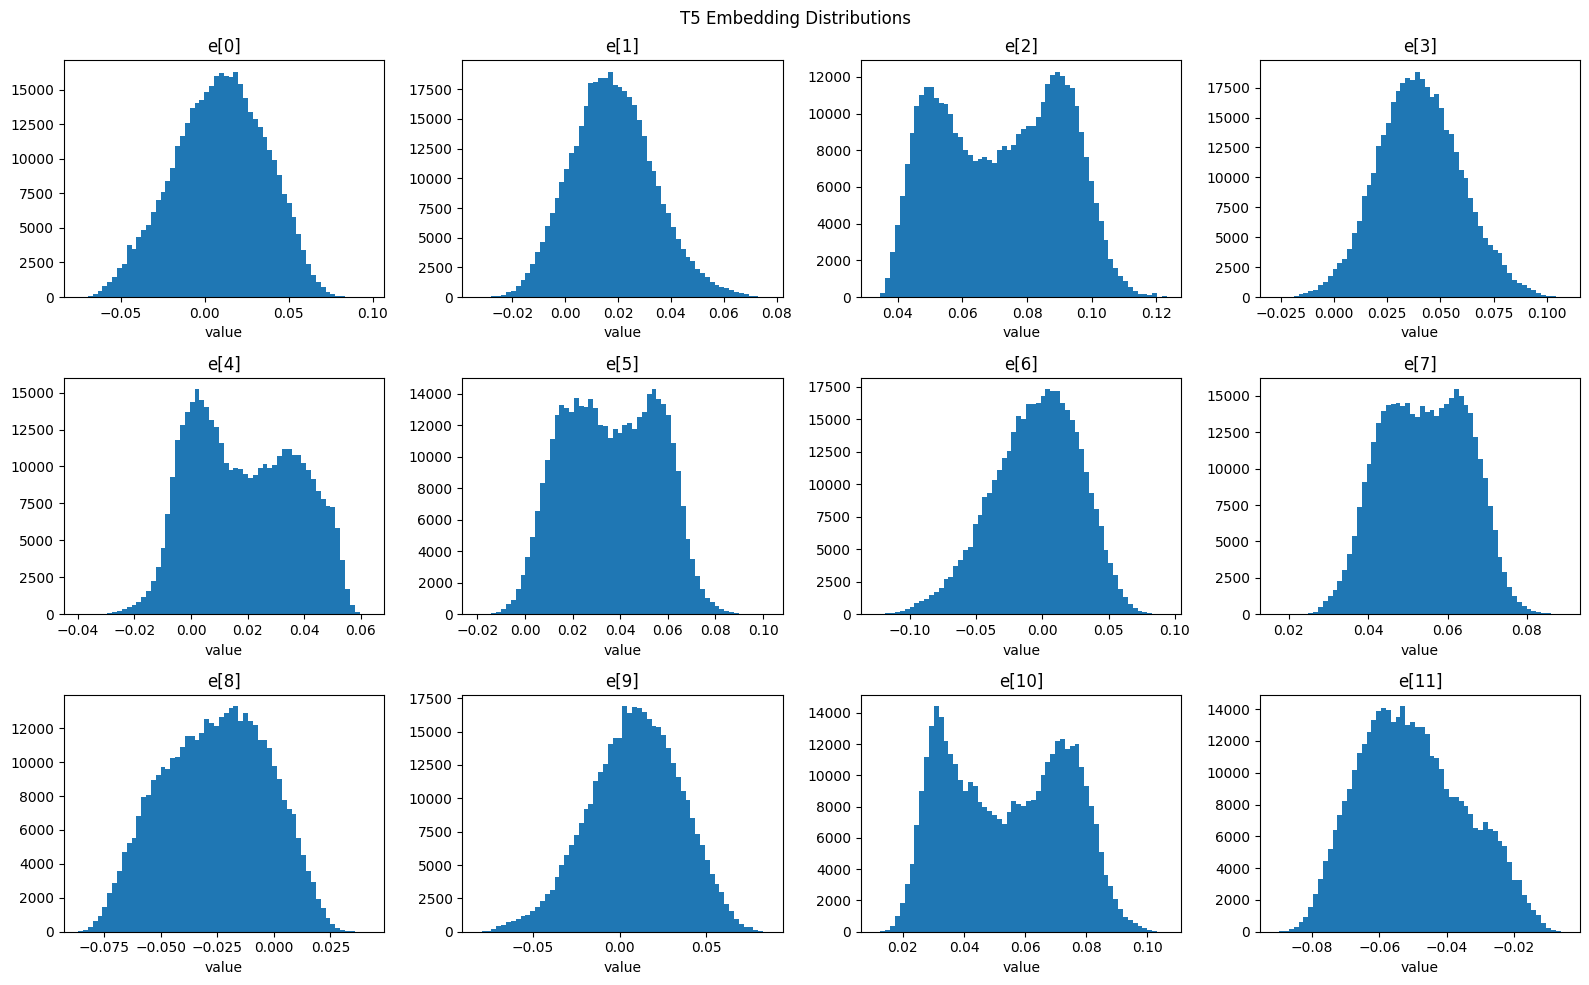

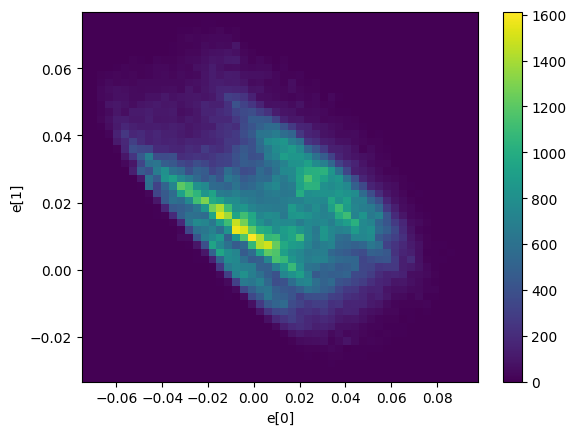

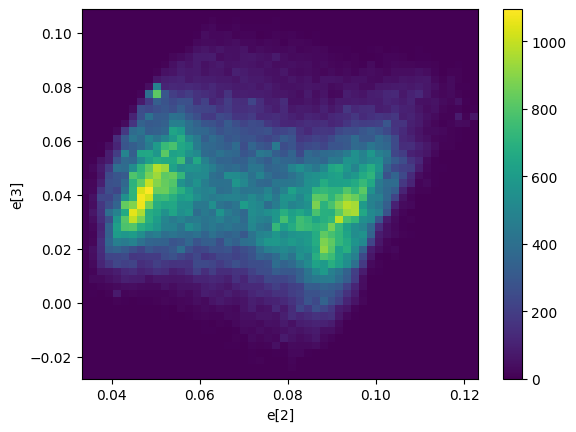

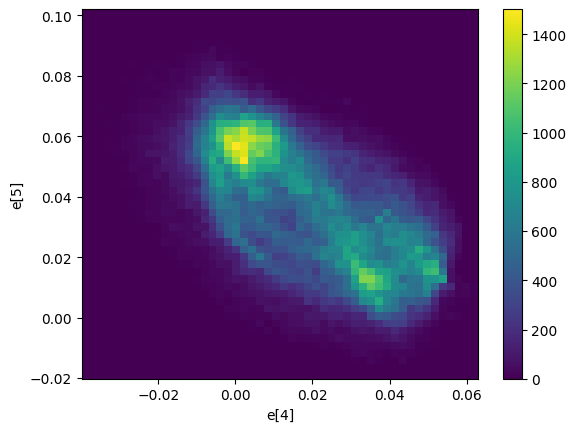

In [10]:
import os
from torch.utils.data import DataLoader

# Same path as cell 9. Override with an absolute path if the notebook runs elsewhere.
CHECKPOINT_PATH = "embedding_training_state.pt"
# True = load all weights, datasets, loaders, optimizers from disk (run cells 1–8 first).
# False = keep tensors already in memory (e.g. you just ran cell 9 in this session).
RESTORE_FROM_CHECKPOINT = os.path.isfile(CHECKPOINT_PATH)

if RESTORE_FROM_CHECKPOINT:
    try:
        ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

    EMB_DIM = ckpt["EMB_DIM"]
    m_metric = MahalanobisMetric(EMB_DIM).to(device)
    moptimizer = optim.Adam(
        list(embed_t5.parameters())
        + list(embed_pls.parameters())
        + list(m_metric.parameters()),
        lr=1e-3,
        weight_decay=1e-4,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        moptimizer, mode="min", factor=0.5, patience=15
    )
    membed_optimizer = optim.Adam(
        list(membed_t5.parameters()) + list(membed_pls.parameters()),
        lr=0.0025,
    )
    optimizer = moptimizer

    embed_t5.load_state_dict(ckpt["embed_t5"])
    embed_pls.load_state_dict(ckpt["embed_pls"])
    cembed_t5.load_state_dict(ckpt["cembed_t5"])
    cembed_pls.load_state_dict(ckpt["cembed_pls"])
    membed_t5.load_state_dict(ckpt["membed_t5"])
    membed_pls.load_state_dict(ckpt["membed_pls"])
    m_metric.load_state_dict(ckpt["m_metric"])

    embed_t5.to(device)
    embed_pls.to(device)
    cembed_t5.to(device)
    cembed_pls.to(device)
    membed_t5.to(device)
    membed_pls.to(device)
    m_metric.to(device)

    scheduler.load_state_dict(ckpt["scheduler"])
    try:
        moptimizer.load_state_dict(ckpt["moptimizer"])
    except Exception:
        moptimizer.load_state_dict(ckpt["optimizer"])
    if "membed_optimizer" in ckpt:
        membed_optimizer.load_state_dict(ckpt["membed_optimizer"])

    num_epochs = ckpt["num_epochs"]
    COV_UPDATE_INTERVAL = ckpt["COV_UPDATE_INTERVAL"]
    MAX_COV_SAMPLES = ckpt["MAX_COV_SAMPLES"]
    batch_size = ckpt["batch_size"]
    num_workers = ckpt["num_workers"]

    train_t5_ds = ckpt["train_t5_ds"]
    test_t5_ds = ckpt["test_t5_ds"]
    train_pls_ds = ckpt["train_pls_ds"]
    test_pls_ds = ckpt["test_pls_ds"]

    train_t5_loader = DataLoader(
        train_t5_ds, batch_size, shuffle=True, num_workers=num_workers, pin_memory=True
    )
    test_t5_loader = DataLoader(
        test_t5_ds, batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )
    train_pls_loader = DataLoader(
        train_pls_ds, batch_size, shuffle=True, num_workers=num_workers, pin_memory=True
    )
    test_pls_loader = DataLoader(
        test_pls_ds, batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )

    c5, ccr = ckpt["cov_t5_final"], ckpt["cov_cross_final"]
    cov_t5_final = None if c5 is None else c5.to(device)
    cov_cross_final = None if ccr is None else ccr.to(device)

    print(f"Restored training state from {CHECKPOINT_PATH}")
else:
    print(
        f"No checkpoint at {CHECKPOINT_PATH} — using in-memory variables "
        "(expected if you just ran cell 9 without saving to this path)."
    )

embed_t5.eval()
all_embs_t5 = []

with torch.no_grad():
    for (l, r, y, _w) in test_t5_loader:
        l, r = l.to(device), r.to(device)
        all_embs_t5.append(embed_t5(l).cpu())
        all_embs_t5.append(embed_t5(r).cpu())

E = torch.cat(all_embs_t5, dim=0).numpy()

fig, axes = plt.subplots(3, 4, figsize=(16, 10)) 
axes = axes.ravel()

for d in range(E.shape[1]):           
    axes[d].hist(E[:, d], bins=60)
    axes[d].set_title(f"e[{d}]")
    axes[d].set_xlabel("value")

plt.suptitle("T5 Embedding Distributions")
plt.tight_layout()
plt.show()

for d in range(0, 6, 2):
    plt.hist2d(E[:, d], E[:, d+1], bins=50)
    plt.xlabel(f"e[{d}]")
    plt.ylabel(f"e[{d+1}]")
    plt.colorbar()
    plt.show()

T5-T5 pairs: 200000 distances
  Range: min=0.0010, max=0.2867
  Labels: similar=100000, dissimilar=100000

T5-T5   Euclidean   AUC: 0.9392
T5-T5   Mahalanobis AUC: 0.9391
T5-T5   Cosine      AUC: 0.7396

pLS-T5  Euclidean   AUC: 0.9186
pLS-T5  Mahalanobis AUC: 0.9208
pLS-T5  Cosine      AUC: 0.4832


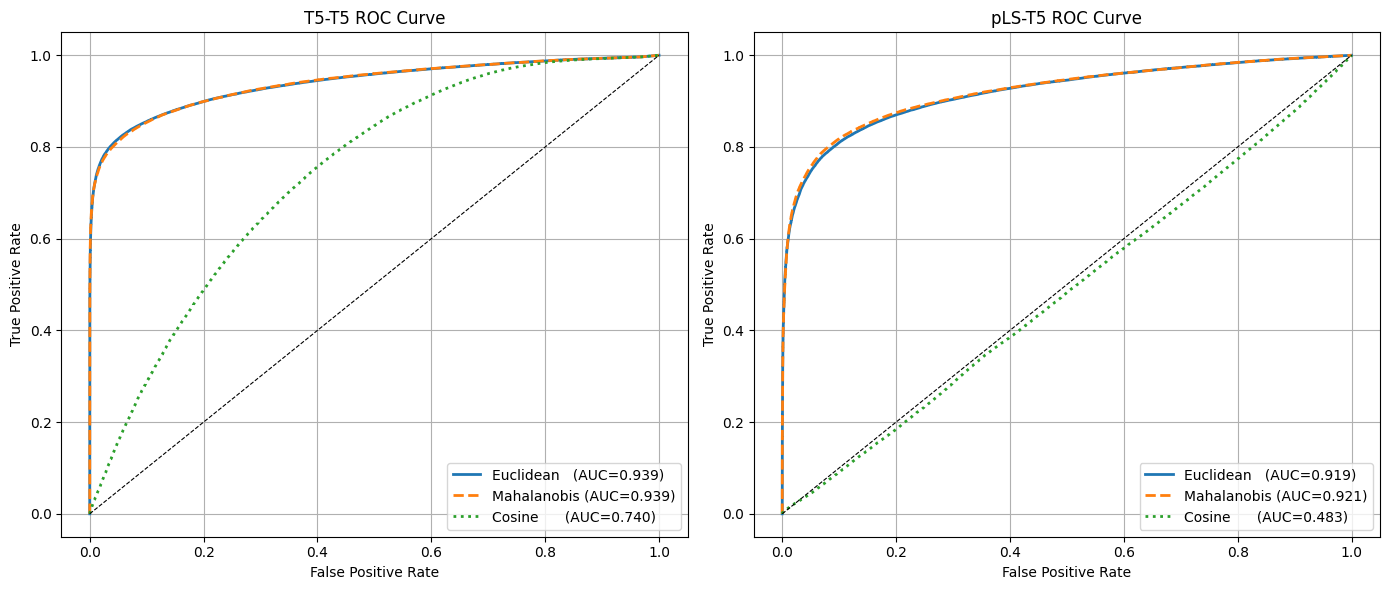

In [12]:
from sklearn.metrics import roc_curve, auc as sklearn_auc
import matplotlib.pyplot as plt

# T5-T5 distances
eucl_d_t5, mahal_d_t5, cos_d_t5, y_t5_list = [], [], [], []

embed_t5.eval(); embed_pls.eval()
cembed_t5.eval(); cembed_pls.eval()

with torch.no_grad():
    for (l, r, y, _w) in test_t5_loader:
        l, r = l.to(device), r.to(device)

        e_l_e = embed_t5(l);   e_r_e = embed_t5(r)
        d_eucl = torch.sqrt(((e_l_e - e_r_e)**2).sum(1, keepdim=True) + 1e-6)
        eucl_d_t5.append(d_eucl.cpu().numpy().ravel())

        d_mah = m_metric(e_l_e, e_r_e, mode='t5')
        mahal_d_t5.append(d_mah.cpu().numpy().ravel())

        e_l_c = cembed_t5(l); e_r_c = cembed_t5(r)
        d_cos = 1.0 - torch.nn.functional.cosine_similarity(e_l_c, e_r_c, dim=1, eps=1e-8).view(-1, 1)
        cos_d_t5.append(d_cos.cpu().numpy().ravel())

        y_t5_list.append(y.numpy().ravel())

eucl_d_t5_arr  = np.concatenate(eucl_d_t5)
mahal_d_t5_arr = np.concatenate(mahal_d_t5)
cos_d_t5_arr   = np.concatenate(cos_d_t5)
y_t5_arr       = np.concatenate(y_t5_list)

# pLS-T5 distances
eucl_d_pls, mahal_d_pls, cos_d_pls, y_pls_list = [], [], [], []

with torch.no_grad():
    for (p5, t5f, y, _w) in test_pls_loader:
        p5, t5f = p5.to(device), t5f.to(device)

        e_p_e = embed_pls(p5);  e_t_e = embed_t5(t5f)
        d_eucl = torch.sqrt(((e_p_e - e_t_e)**2).sum(1, keepdim=True) + 1e-6)
        eucl_d_pls.append(d_eucl.cpu().numpy().ravel())

        d_mah = m_metric(e_p_e, e_t_e, mode='cross')
        mahal_d_pls.append(d_mah.cpu().numpy().ravel())

        e_p_c = cembed_pls(p5); e_t_c = cembed_t5(t5f)
        d_cos = 1.0 - torch.nn.functional.cosine_similarity(e_p_c, e_t_c, dim=1, eps=1e-8).view(-1, 1)
        cos_d_pls.append(d_cos.cpu().numpy().ravel())

        y_pls_list.append(y.numpy().ravel())

eucl_d_pls_arr  = np.concatenate(eucl_d_pls)
mahal_d_pls_arr = np.concatenate(mahal_d_pls)
cos_d_pls_arr   = np.concatenate(cos_d_pls)
y_pls_arr       = np.concatenate(y_pls_list)

print(f"T5-T5 pairs: {len(y_t5_arr)} distances")
print(f"  Range: min={eucl_d_t5_arr.min():.4f}, max={eucl_d_t5_arr.max():.4f}")
print(f"  Labels: similar={int((y_t5_arr==0).sum())}, dissimilar={int((y_t5_arr==1).sum())}")

fpr_e_t5,  tpr_e_t5,  _ = roc_curve(y_t5_arr, eucl_d_t5_arr)
fpr_m_t5,  tpr_m_t5,  _ = roc_curve(y_t5_arr, mahal_d_t5_arr)
fpr_c_t5,  tpr_c_t5,  _ = roc_curve(y_t5_arr, cos_d_t5_arr)
fpr_e_pls, tpr_e_pls, _ = roc_curve(y_pls_arr, eucl_d_pls_arr)
fpr_m_pls, tpr_m_pls, _ = roc_curve(y_pls_arr, mahal_d_pls_arr)
fpr_c_pls, tpr_c_pls, _ = roc_curve(y_pls_arr, cos_d_pls_arr)

auc_e_t5  = sklearn_auc(fpr_e_t5,  tpr_e_t5)
auc_m_t5  = sklearn_auc(fpr_m_t5,  tpr_m_t5)
auc_c_t5  = sklearn_auc(fpr_c_t5,  tpr_c_t5)
auc_e_pls = sklearn_auc(fpr_e_pls, tpr_e_pls)
auc_m_pls = sklearn_auc(fpr_m_pls, tpr_m_pls)
auc_c_pls = sklearn_auc(fpr_c_pls, tpr_c_pls)

print(f"\nT5-T5   Euclidean   AUC: {auc_e_t5:.4f}")
print(f"T5-T5   Mahalanobis AUC: {auc_m_t5:.4f}")
print(f"T5-T5   Cosine      AUC: {auc_c_t5:.4f}")
print(f"\npLS-T5  Euclidean   AUC: {auc_e_pls:.4f}")
print(f"pLS-T5  Mahalanobis AUC: {auc_m_pls:.4f}")
print(f"pLS-T5  Cosine      AUC: {auc_c_pls:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr_e_t5, tpr_e_t5, label=f"Euclidean   (AUC={auc_e_t5:.3f})", linewidth=2)
axes[0].plot(fpr_m_t5, tpr_m_t5, label=f"Mahalanobis (AUC={auc_m_t5:.3f})", linewidth=2, linestyle='--')
axes[0].plot(fpr_c_t5, tpr_c_t5, label=f"Cosine      (AUC={auc_c_t5:.3f})", linewidth=2, linestyle=':')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("T5-T5 ROC Curve"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(fpr_e_pls, tpr_e_pls, label=f"Euclidean   (AUC={auc_e_pls:.3f})", linewidth=2)
axes[1].plot(fpr_m_pls, tpr_m_pls, label=f"Mahalanobis (AUC={auc_m_pls:.3f})", linewidth=2, linestyle='--')
axes[1].plot(fpr_c_pls, tpr_c_pls, label=f"Cosine      (AUC={auc_c_pls:.3f})", linewidth=2, linestyle=':')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("pLS-T5 ROC Curve"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


/home/users/aiden/Duplicate-Charged-Particle-Tracks-with-ML-professor-Tuna-1/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


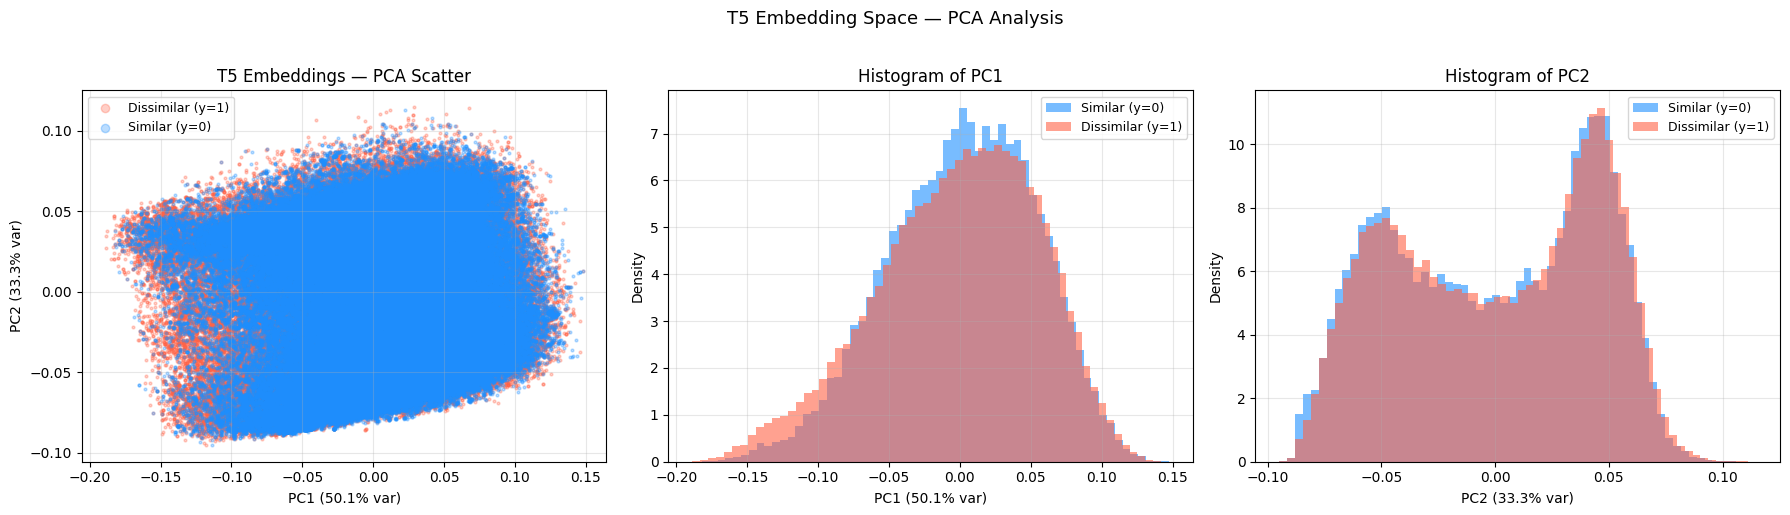


Explained variance by component:
  PC1: 50.07%
  PC2: 33.30%
  Total (PC1+PC2): 83.37%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

embed_t5.eval()
all_embs_t5 = []
all_labels_t5 = []

with torch.no_grad():
    for (l, r, y, _w) in test_t5_loader:
        l, r = l.to(device), r.to(device)
        all_embs_t5.append(embed_t5(l).cpu())
        all_embs_t5.append(embed_t5(r).cpu())
        all_labels_t5.append(y.squeeze().cpu())
        all_labels_t5.append(y.squeeze().cpu())

E = torch.cat(all_embs_t5, dim=0).numpy()
labels = torch.cat(all_labels_t5, dim=0).numpy()  # 0=similar, 1=dissimilar

# ── PCA ──
pca = PCA(n_components=2)
E_pca = pca.fit_transform(E)

explained = pca.explained_variance_ratio_

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: scatter of PC1 vs PC2, coloured by label
ax = axes[0]
sim_mask  = labels == 0
dis_mask  = labels == 1
ax.scatter(E_pca[dis_mask,  0], E_pca[dis_mask,  1],
           c='tomato',      alpha=0.3, s=4, label='Dissimilar (y=1)')
ax.scatter(E_pca[sim_mask,  0], E_pca[sim_mask,  1],
           c='dodgerblue',  alpha=0.3, s=4, label='Similar (y=0)')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title('T5 Embeddings — PCA Scatter')
ax.legend(markerscale=3, fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: histogram of PC1 by label
ax = axes[1]
ax.hist(E_pca[sim_mask, 0], bins=60, alpha=0.6,
        color='dodgerblue', label='Similar (y=0)', density=True)
ax.hist(E_pca[dis_mask, 0], bins=60, alpha=0.6,
        color='tomato',     label='Dissimilar (y=1)', density=True)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel('Density')
ax.set_title('Histogram of PC1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: histogram of PC2 by label
ax = axes[2]
ax.hist(E_pca[sim_mask, 1], bins=60, alpha=0.6,
        color='dodgerblue', label='Similar (y=0)', density=True)
ax.hist(E_pca[dis_mask, 1], bins=60, alpha=0.6,
        color='tomato',     label='Dissimilar (y=1)', density=True)
ax.set_xlabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_ylabel('Density')
ax.set_title('Histogram of PC2')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('T5 Embedding Space — PCA Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nExplained variance by component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")
print(f"  Total (PC1+PC2): {sum(pca.explained_variance_ratio_)*100:.2f}%")


Explained variance for all 12 components:
  PC01:  50.07% (Cumulative:  50.07%)
  PC02:  33.30% (Cumulative:  83.37%)
  PC03:  12.45% (Cumulative:  95.82%)
  PC04:   1.74% (Cumulative:  97.56%)
  PC05:   1.02% (Cumulative:  98.58%)
  PC06:   0.56% (Cumulative:  99.13%)
  PC07:   0.31% (Cumulative:  99.44%)
  PC08:   0.23% (Cumulative:  99.67%)
  PC09:   0.13% (Cumulative:  99.80%)
  PC10:   0.11% (Cumulative:  99.91%)
  PC11:   0.05% (Cumulative:  99.96%)
  PC12:   0.04% (Cumulative: 100.00%)


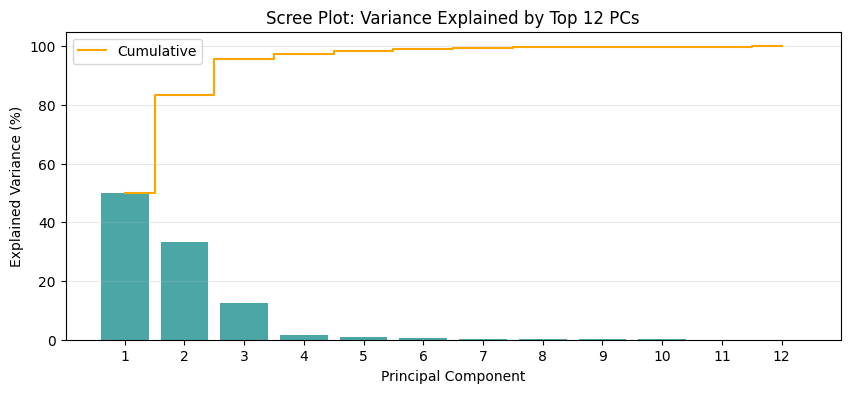

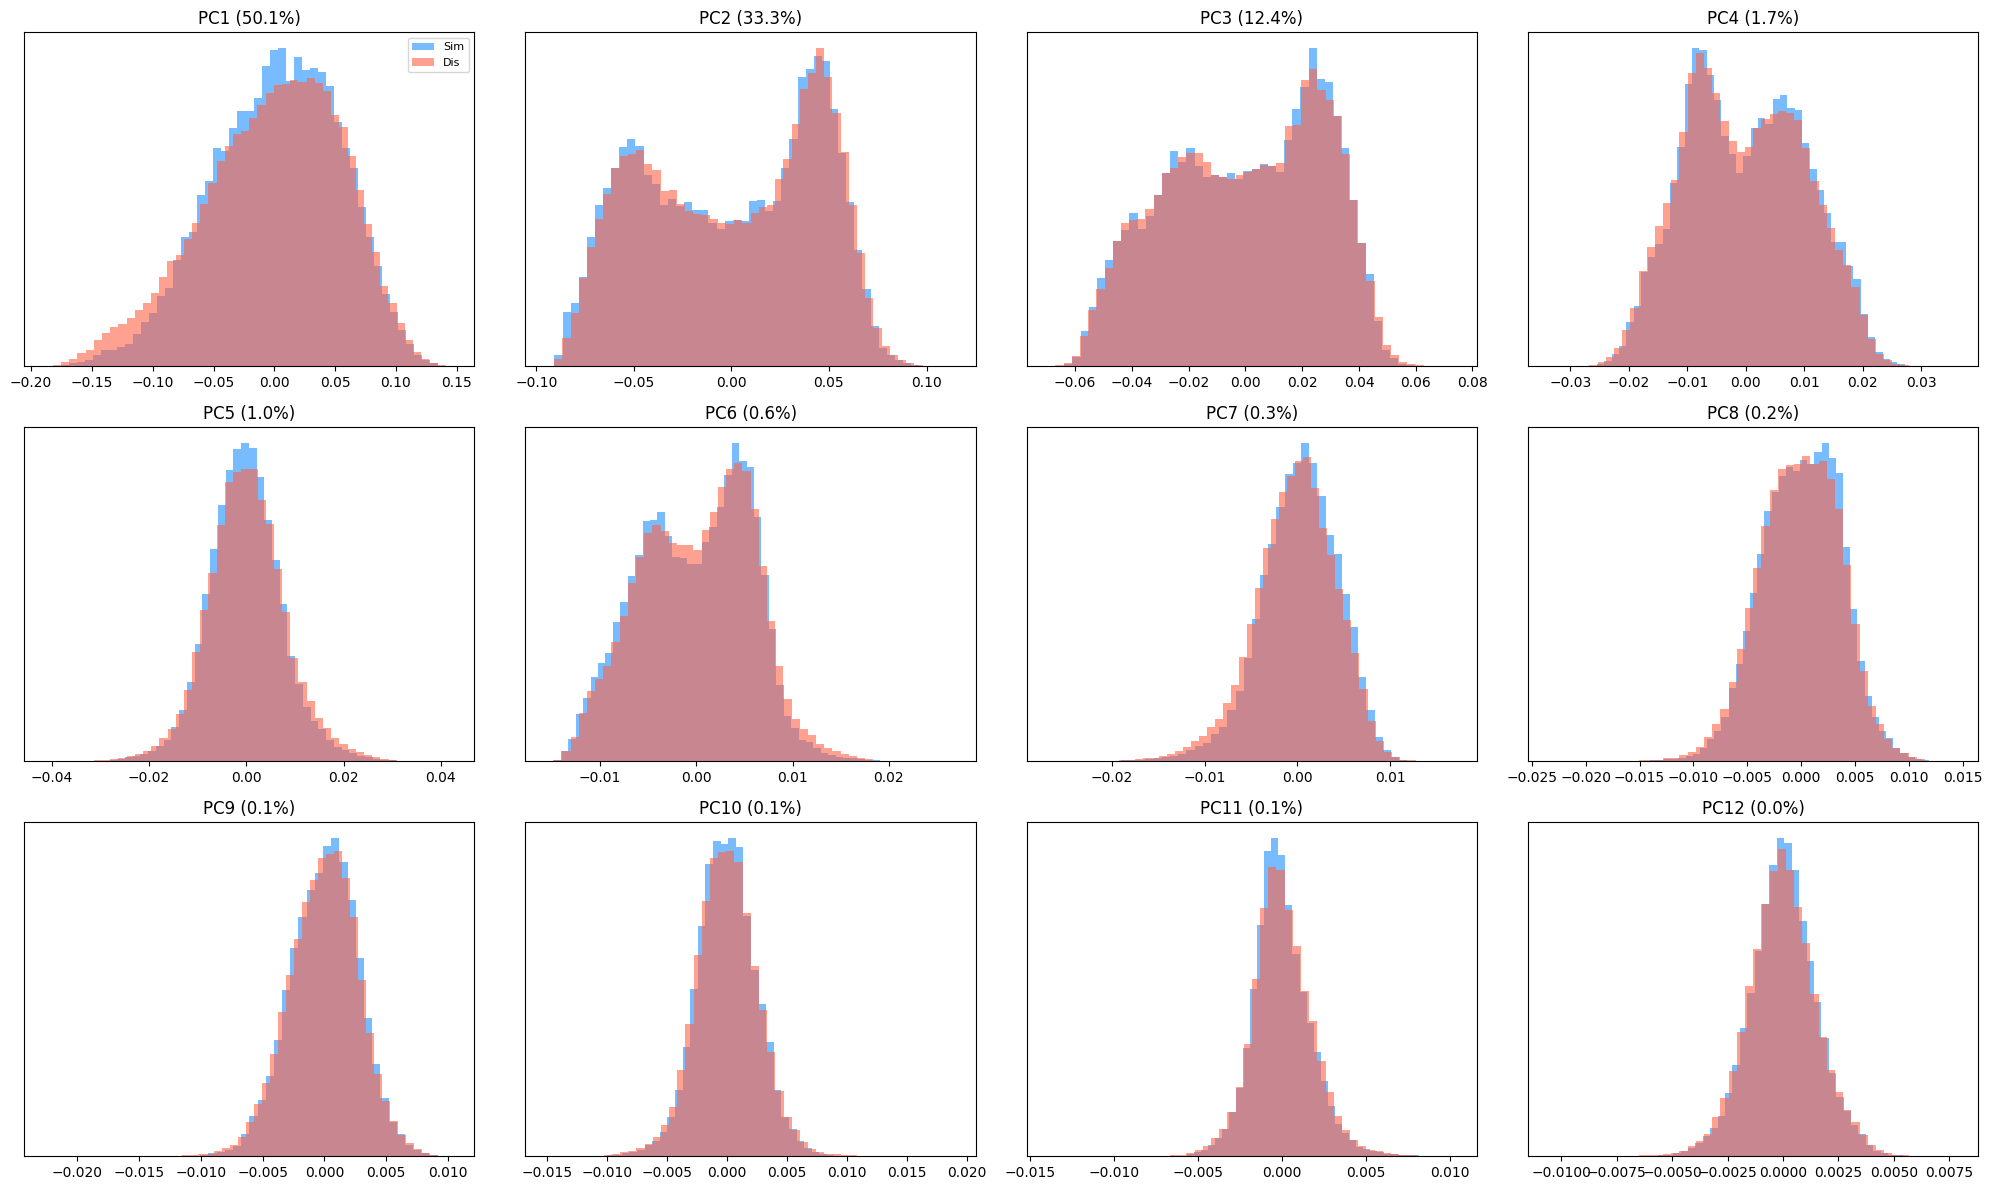

In [14]:
# ── Updated PCA for 12 Components ──
n_comp = 12
pca = PCA(n_components=n_comp)
E_pca = pca.fit_transform(E)

# ── Print Variance Explained for all 12 ──
print(f"\nExplained variance for all {n_comp} components:")
cumulative_var = 0
for i, v in enumerate(pca.explained_variance_ratio_):
    cumulative_var += v
    print(f"  PC{i+1:02d}: {v*100:6.2f}% (Cumulative: {cumulative_var*100:6.2f}%)")

# ── Optional: Visualize the Variance Distribution (Scree Plot) ──
plt.figure(figsize=(10, 4))
plt.bar(range(1, n_comp + 1), pca.explained_variance_ratio_ * 100, color='teal', alpha=0.7)
plt.step(range(1, n_comp + 1), np.cumsum(pca.explained_variance_ratio_) * 100, where='mid', color='orange', label='Cumulative')
plt.xticks(range(1, n_comp + 1))
plt.ylabel('Explained Variance (%)')
plt.xlabel('Principal Component')
plt.title('Scree Plot: Variance Explained by Top 12 PCs')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# ── Optional: Plot Histograms for all 12 to see separation ──
fig, axes = plt.subplots(3, 4, figsize=(20, 12))  # 3x4 grid for 12 components
axes = axes.flatten()

sim_mask = labels == 0
dis_mask = labels == 1

for i in range(n_comp):
    ax = axes[i]
    ax.hist(E_pca[sim_mask, i], bins=50, alpha=0.6, color='dodgerblue', label='Sim', density=True)
    ax.hist(E_pca[dis_mask, i], bins=50, alpha=0.6, color='tomato', label='Dis', density=True)
    ax.set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    ax.set_yticks([]) # Clean up the look
    if i == 0: ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
# ── Extended training (100 epochs) ──────────────────────────────────────────
# Mahalanobis branch: uses m_metric, loss_reg, grad-clip, cov updates, scheduler
# (mirrors the main training loop exactly)

num_epochs = 100

for epoch in range(1, num_epochs + 1):
    embed_t5.train(); embed_pls.train()
    total_loss, total_t5, total_pls, total_reg = 0.0, 0.0, 0.0, 0.0

    do_cov_update = (epoch % COV_UPDATE_INTERVAL == 0)
    sim_embs_t5    = []
    sim_embs_cross = []
    collected_t5    = 0
    collected_cross = 0

    for (l, r, y0, w0), (p5, t5f, y1, w1) in zip(train_t5_loader, train_pls_loader):
        l,   r    = l.to(device),   r.to(device)
        y0_, w0_  = y0.to(device),  w0.to(device)
        p5,  t5f_ = p5.to(device),  t5f.to(device)
        y1_, w1_  = y1.to(device),  w1.to(device)

        e_l = embed_t5(l);   e_r = embed_t5(r)
        d0  = m_metric(e_l, e_r, mode='t5')
        loss0 = criterion(d0, y0_, w0_)

        e_p5 = embed_pls(p5); e_t5 = embed_t5(t5f_)
        d1   = m_metric(e_p5, e_t5, mode='cross')
        loss1 = criterion(d1, y1_, w1_)

        e_all = torch.cat([e_l, e_r], dim=0)
        cov_batch = torch.cov(e_all.T)
        eye_emb = torch.eye(EMB_DIM, device=device, dtype=cov_batch.dtype)
        loss_reg = 0.01 * (cov_batch - eye_emb).pow(2).mean()

        loss = loss0 + loss1 + loss_reg

        moptimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embed_t5.parameters()) + list(embed_pls.parameters()),
            max_norm=5.0,
        )
        moptimizer.step()

        total_loss += loss.item()
        total_t5   += loss0.item()
        total_pls  += loss1.item()
        total_reg  += loss_reg.detach().item()

        if do_cov_update:
            sim_t5_mask = (y0_.squeeze() == 0)
            if sim_t5_mask.any() and collected_t5 < MAX_COV_SAMPLES:
                sim_embs_t5.append(e_l[sim_t5_mask].detach())
                sim_embs_t5.append(e_r[sim_t5_mask].detach())
                collected_t5 += sim_t5_mask.sum().item() * 2

            sim_pls_mask = (y1_.squeeze() == 0)
            if sim_pls_mask.any() and collected_cross < MAX_COV_SAMPLES:
                sim_embs_cross.append(e_p5[sim_pls_mask].detach())
                sim_embs_cross.append(e_t5[sim_pls_mask].detach())
                collected_cross += sim_pls_mask.sum().item() * 2

    if do_cov_update:
        print(f"  [Epoch {epoch}] Updating precision matrices...")
        cov_t5, cov_cross = m_metric.update_v(sim_embs_t5, sim_embs_cross)
        if cov_t5 is not None:
            cov_t5_final = cov_t5
        if cov_cross is not None:
            cov_cross_final = cov_cross

    avg_loss = total_loss / len(train_pls_loader)
    avg_t5   = total_t5   / len(train_t5_loader)
    avg_pls  = total_pls  / len(train_pls_loader)
    avg_reg  = total_reg  / len(train_pls_loader)
    scheduler.step(avg_loss)

    print(f"Epoch {epoch}/{num_epochs}:  JointLoss={avg_loss:.4f}  "
          f"T5={avg_t5:.4f}  pLS={avg_pls:.4f}  Reg={avg_reg:.4f}")

# ── Cosine branch (cembed): unchanged ────────────────────────────────────────
coptimizer = optim.Adam(
    list(cembed_t5.parameters()) + list(cembed_pls.parameters()), lr=0.0025
)

for epoch in range(1, num_epochs + 1):
    cembed_t5.train(); cembed_pls.train()
    ctotal_loss = 0.0

    for (l, r, y0, w0), (p5, t5f, y1, w1) in zip(train_t5_loader, train_pls_loader):
        l, r, y0_, w0_ = l.to(device), r.to(device), y0.to(device), w0.to(device)
        p5, t5f_, y1_, w1_ = p5.to(device), t5f.to(device), y1.to(device), w1.to(device)

        e_l, e_r = cembed_t5(l), cembed_t5(r)
        d0 = 1.0 - torch.nn.functional.cosine_similarity(e_l, e_r, dim=1, eps=1e-8).view(-1, 1)
        loss0 = coscriterion(d0, y0_, w0_)

        e_p5 = cembed_pls(p5)
        e_t5 = cembed_t5(t5f_)
        d1 = 1.0 - torch.nn.functional.cosine_similarity(e_p5, e_t5, dim=1, eps=1e-8).view(-1, 1)
        loss1 = coscriterion(d1, y1_, w1_)

        loss = loss0 + loss1
        coptimizer.zero_grad()
        loss.backward()
        coptimizer.step()
        ctotal_loss += loss.item()

    if epoch % 20 == 0:
        print(f"Cosine Epoch {epoch}: Loss={ctotal_loss/len(train_pls_loader):.4f}")


Epoch 1/100:  JointLoss=0.2914  T5=0.1418  pLS=0.1487  Reg=0.0008


Exception ignored in: <function _releaseLock at 0x7fb4b6ad0dc0>
Traceback (most recent call last):
  File "/usr/lib64/python3.9/logging/__init__.py", line 227, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 


RuntimeError: DataLoader worker (pid(s) 3870269, 3870275, 3870276, 3870277, 3870278, 3870279, 3870283, 3870284) exited unexpectedly

In [ ]:
#Don't run this cell
for epoch in range(1, num_epochs+1):
    membed_t5.train(); membed_pls.train()
    mtotal_loss, mtotal_t5, mtotal_pls = 0.0, 0.0, 0.0

    for (l, r, y0, w0), (p5, t5f, y1, w1) in zip(train_t5_loader, train_pls_loader):
        l, r, y0_, w0_ = l.to(device), r.to(device), y0.to(device), w0.to(device)
        p5, t5f_, y1_, w1_ = p5.to(device), t5f.to(device), y1.to(device), w1.to(device)

        e_l = membed_t5(l)
        e_r = membed_t5(r)
        d0 = torch.sqrt(((e_l - e_r)**2).sum(1, keepdim=True) + 1e-6)
        loss0 = criterion(d0, y0_, w0_)

        e_p5 = membed_pls(p5)
        e_t5 = membed_t5(t5f_)
        d1 = torch.sqrt(((e_p5 - e_t5)**2).sum(1, keepdim=True) + 1e-6)
        loss1 = criterion(d1, y1_, w1_)

        loss = loss0 + loss1
        membed_optimizer.zero_grad()
        loss.backward()
        membed_optimizer.step()

        mtotal_loss += loss.item()
        mtotal_t5 += loss0.item()
        mtotal_pls += loss1.item()

    avg_loss   = mtotal_loss / len(train_pls_loader)
    avg_t5     = mtotal_t5   / len(train_t5_loader)
    avg_pls    = mtotal_pls  / len(train_pls_loader)
    print(f"Epoch {epoch}/{num_epochs}:  JointLoss={avg_loss:.4f}  "
          f"T5={avg_t5:.4f}  pLS={avg_pls:.4f}")


T5-T5 pairs: 8000 distances
  Range: min=0.0010, max=6.0256
  Labels: similar=4000, dissimilar=4000

T5-T5   Euclidean   AUC: 0.9459
T5-T5   Mahalanobis AUC: 0.9338
T5-T5   Cosine      AUC: 0.9327

pLS-T5  Euclidean   AUC: 0.9218
pLS-T5  Mahalanobis AUC: 0.8820
pLS-T5  Cosine      AUC: 0.9330


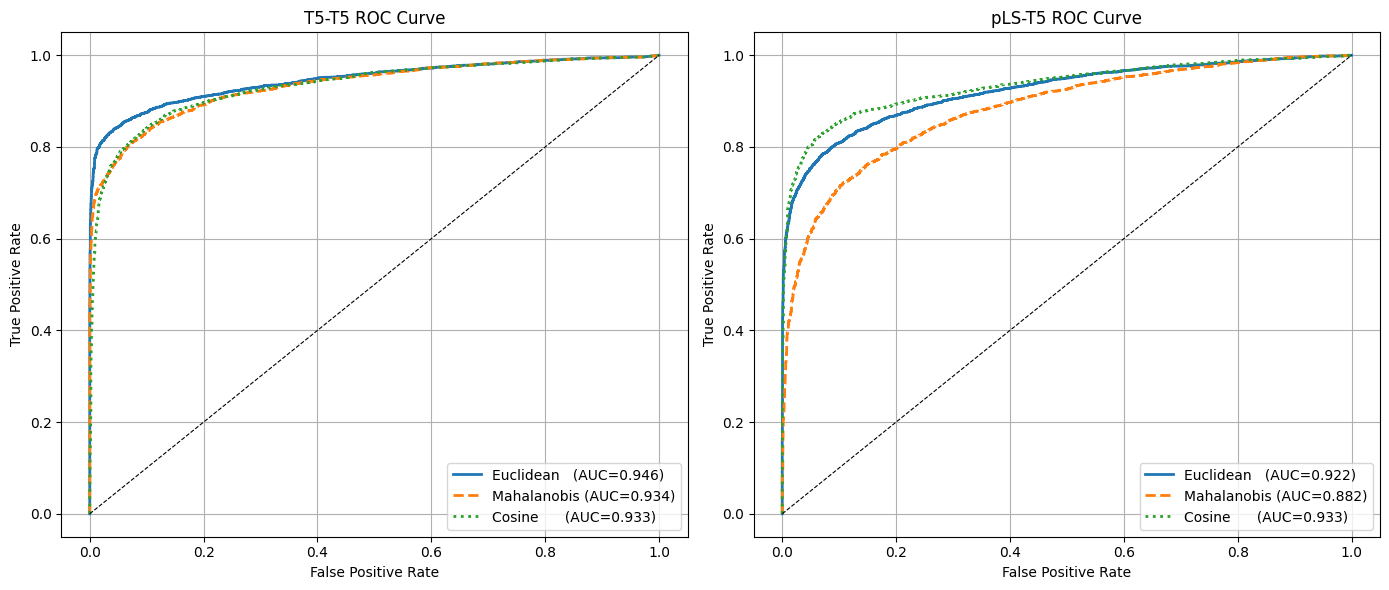

In [ ]:
from sklearn.metrics import roc_curve, auc as sklearn_auc
import matplotlib.pyplot as plt

# T5-T5 distances
eucl_d_t5, mahal_d_t5, cos_d_t5, y_t5_list = [], [], [], []

embed_t5.eval(); embed_pls.eval()
cembed_t5.eval(); cembed_pls.eval()

with torch.no_grad():
    for (l, r, y, _w) in test_t5_loader:
        l, r = l.to(device), r.to(device)

        e_l_e = embed_t5(l);   e_r_e = embed_t5(r)
        d_eucl = torch.sqrt(((e_l_e - e_r_e)**2).sum(1, keepdim=True) + 1e-6)
        eucl_d_t5.append(d_eucl.cpu().numpy().ravel())

        d_mah = m_metric(e_l_e, e_r_e, mode='t5')
        mahal_d_t5.append(d_mah.cpu().numpy().ravel())

        e_l_c = cembed_t5(l); e_r_c = cembed_t5(r)
        d_cos = 1.0 - torch.nn.functional.cosine_similarity(e_l_c, e_r_c, dim=1, eps=1e-8).view(-1, 1)
        cos_d_t5.append(d_cos.cpu().numpy().ravel())

        y_t5_list.append(y.numpy().ravel())

eucl_d_t5_arr  = np.concatenate(eucl_d_t5)
mahal_d_t5_arr = np.concatenate(mahal_d_t5)
cos_d_t5_arr   = np.concatenate(cos_d_t5)
y_t5_arr       = np.concatenate(y_t5_list)

# pLS-T5 distances
eucl_d_pls, mahal_d_pls, cos_d_pls, y_pls_list = [], [], [], []

with torch.no_grad():
    for (p5, t5f, y, _w) in test_pls_loader:
        p5, t5f = p5.to(device), t5f.to(device)

        e_p_e = embed_pls(p5);  e_t_e = embed_t5(t5f)
        d_eucl = torch.sqrt(((e_p_e - e_t_e)**2).sum(1, keepdim=True) + 1e-6)
        eucl_d_pls.append(d_eucl.cpu().numpy().ravel())

        d_mah = m_metric(e_p_e, e_t_e, mode='cross')
        mahal_d_pls.append(d_mah.cpu().numpy().ravel())

        e_p_c = cembed_pls(p5); e_t_c = cembed_t5(t5f)
        d_cos = 1.0 - torch.nn.functional.cosine_similarity(e_p_c, e_t_c, dim=1, eps=1e-8).view(-1, 1)
        cos_d_pls.append(d_cos.cpu().numpy().ravel())

        y_pls_list.append(y.numpy().ravel())

eucl_d_pls_arr  = np.concatenate(eucl_d_pls)
mahal_d_pls_arr = np.concatenate(mahal_d_pls)
cos_d_pls_arr   = np.concatenate(cos_d_pls)
y_pls_arr       = np.concatenate(y_pls_list)

print(f"T5-T5 pairs: {len(y_t5_arr)} distances")
print(f"  Range: min={eucl_d_t5_arr.min():.4f}, max={eucl_d_t5_arr.max():.4f}")
print(f"  Labels: similar={int((y_t5_arr==0).sum())}, dissimilar={int((y_t5_arr==1).sum())}")

fpr_e_t5,  tpr_e_t5,  _ = roc_curve(y_t5_arr, eucl_d_t5_arr)
fpr_m_t5,  tpr_m_t5,  _ = roc_curve(y_t5_arr, mahal_d_t5_arr)
fpr_c_t5,  tpr_c_t5,  _ = roc_curve(y_t5_arr, cos_d_t5_arr)
fpr_e_pls, tpr_e_pls, _ = roc_curve(y_pls_arr, eucl_d_pls_arr)
fpr_m_pls, tpr_m_pls, _ = roc_curve(y_pls_arr, mahal_d_pls_arr)
fpr_c_pls, tpr_c_pls, _ = roc_curve(y_pls_arr, cos_d_pls_arr)

auc_e_t5  = sklearn_auc(fpr_e_t5,  tpr_e_t5)
auc_m_t5  = sklearn_auc(fpr_m_t5,  tpr_m_t5)
auc_c_t5  = sklearn_auc(fpr_c_t5,  tpr_c_t5)
auc_e_pls = sklearn_auc(fpr_e_pls, tpr_e_pls)
auc_m_pls = sklearn_auc(fpr_m_pls, tpr_m_pls)
auc_c_pls = sklearn_auc(fpr_c_pls, tpr_c_pls)

print(f"\nT5-T5   Euclidean   AUC: {auc_e_t5:.4f}")
print(f"T5-T5   Mahalanobis AUC: {auc_m_t5:.4f}")
print(f"T5-T5   Cosine      AUC: {auc_c_t5:.4f}")
print(f"\npLS-T5  Euclidean   AUC: {auc_e_pls:.4f}")
print(f"pLS-T5  Mahalanobis AUC: {auc_m_pls:.4f}")
print(f"pLS-T5  Cosine      AUC: {auc_c_pls:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr_e_t5, tpr_e_t5, label=f"Euclidean   (AUC={auc_e_t5:.3f})", linewidth=2)
axes[0].plot(fpr_m_t5, tpr_m_t5, label=f"Mahalanobis (AUC={auc_m_t5:.3f})", linewidth=2, linestyle='--')
axes[0].plot(fpr_c_t5, tpr_c_t5, label=f"Cosine      (AUC={auc_c_t5:.3f})", linewidth=2, linestyle=':')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("T5-T5 ROC Curve"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(fpr_e_pls, tpr_e_pls, label=f"Euclidean   (AUC={auc_e_pls:.3f})", linewidth=2)
axes[1].plot(fpr_m_pls, tpr_m_pls, label=f"Mahalanobis (AUC={auc_m_pls:.3f})", linewidth=2, linestyle='--')
axes[1].plot(fpr_c_pls, tpr_c_pls, label=f"Cosine      (AUC={auc_c_pls:.3f})", linewidth=2, linestyle=':')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("pLS-T5 ROC Curve"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
!git add -A && git commit -m "auto save" && git push

[main 8a8cff2] auto save
 6 files changed, 2773 insertions(+), 116 deletions(-)
 create mode 100644 Compressed_data.npz
 create mode 100644 Uncompressed_data.npz
 create mode 100644 embedding_training_state.pt
 create mode 100644 ml_ready_data.pkl
 create mode 100644 updated_fixed-3.ipynb

(gnome-ssh-askpass:3871520): Gtk-WARNING **: 18:05:22.937: cannot open display: 
error: unable to read askpass response from '/usr/libexec/openssh/gnome-ssh-askpass'
Username for 'https://github.com': 